# 1.利用LangGraph框架创建简单聊天机器人

状态

In [ ]:
from typing import List, Dict
from pydantic import BaseModel
class ChatState(BaseModel):
    messages: List[Dict[str, str]] = []
    current_input: str = ""
    tools_output: Dict[str, str] = {}
    final_response: str = ""

节点

In [ ]:
async def process_input(state: ChatState) -> ChatState:
    messages = state.messages + [{"role": "user", "content": state.current_input}]
    return ChatState(
        messages=messages,
        current_input=state.current_input,
        tools_output=state.tools_output
    )

async def generate_response(state:ChatState) -> ChatState:
    response = await llm.ainvoke(state.message)
    messages = state.messages + [{"role": "assistant", "content": response}]
    return ChatState(
        messages=messages,
        current_input=state.current_input,
        tools_output=state.tools_output,
        final_response=response
    )

边

In [ ]:
from langgraph.graph import StateGraph, END #构建状态驱动的有向图工作流
# 创建图结构
workflow = StateGraph(ChatState)
# 添加节点
workflow.add_node("process_input", process_input)
workflow.add_node("generate_response", generate_response)
# 定义边和路由逻辑（节点之间的执行顺序）
workflow.add_edge("process_input","generate_response")
workflow.add_edge("generate_response", END)


简单聊天机器人

In [ ]:
from typing import List, Dict, Tuple
from pydantic import BaseModel
from langgraph.graph import StateGraph, END
from langchain_core.language_models import ChatOpenAI

#1.定义状态
class ChatState(BaseModel):
    message: List[Dict[str,str]]=[]
    current_input: str=""
    should_continue: bool=True

#2.定义节点函数
async def process_user_input(state:ChatState) -> ChatState:
    """处理用户输入"""
    messages = state.messages + [{"role":"user","content":state.current_input}]
    return ChatState(
        messages=messages,
        current_input=state.current_input,
        should_continue=True
    )
async def generate_ai_response(state:ChatState) -> ChatState:
    """生成AI回复"""
    llm = ChatOpenAI(temperature=0.7) #采样参数：控制模型生成文本时的“随机性”-->取值怕[0.0,1.0](甚至更高)
    response = await llm.ainvoke(state.messages) #Python 的异步函数只有在 await 或 asyncio.run() 中被调度时才会真正执行
    messages = state.messages + [{"role":"assistant","content": response}]
    return ChatState(
        messages=messages,
        current_input=state.current_input,
        should_continue=True
    )
def should_continue(state:ChatState) -> str:
    """决定是否继续对话"""
    if "goodbye" in state.current_input.lower(): #lower表示将用户输入全部转为小写字母
        return "end" 
    return "continue"

#3.构建图
workflow = StateGraph(ChatState)
#添加节点
workflow.add_node("process_input",process_user_input)
workflow.add_node("generate_response",generate_ai_response)
#添加边
workflow.add_edge("process_input","generate_response")
workflow.add_conditional_edges(
    "generate_response", #表示这个节点有条件分支
    should_continue,
    {
        "continue":"process_input",
        "end":END
    }                   #定义了条件返回值对应的节点
)

#4.编译图
app = workflow.compile() #把图结构转换为可直接调用的程序接口

#5.运行对话
async def chat():
    state = ChatState()


# 2.利用LangGraph框架构建智能太阳能节能助手

 AWS Bedrock是AWS官方提供完全托管的服务，让开发者能够通过 API 轻松访问来自领先 AI 公司的高性能基础模型（FM），并使用自己的数据对其进行定制，而无需管理任何基础设施。

In [ ]:
###1.导入库
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda
from langchain_aws import ChatBedrock

from langgraph.graph import StateGraph, START 
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

import boto3
from typing import Annotated
from typing_extensions import TypedDict

### 2. 定义节能计算工具
@tool # 可以被包装成langchain Tool对象-->被agent调用
def compute_savings(monthly_cost: float) -> float:
    """
    工具功能：根据用户每月电费计算切换到太阳能后的潜在节省。

    参数:
        monthly_cost (float): 用户当前每月电费支出（单位：美元）

    返回:
        dict: 包含以下内容的字典：
            - 'number_of_panels': 预计所需太阳能板数量
            - 'installation_cost': 安装费用估算
            - 'net_savings_10_years': 安装后10年内的净节省金额
    """
    def calculate_solar_savings(monthly_cost):
        # 计算的基础假设值
        cost_per_kWh = 0.28              # 每度电（千瓦时）价格（美元）
        cost_per_watt = 1.50             # 每瓦安装成本（美元）
        sunlight_hours_per_day = 3.5     # 平均每日日照时长（小时）
        panel_wattage = 350              # 单块太阳能板功率（瓦）
        system_lifetime_years = 10       # 系统使用年限

        # 用户每月用电量（kWh）
        monthly_consumption_kWh = monthly_cost / cost_per_kWh

        # 系统所需功率（千瓦）
        daily_energy_production = monthly_consumption_kWh / 30
        system_size_kW = daily_energy_production / sunlight_hours_per_day

        # 计算面板数量和安装成本
        number_of_panels = system_size_kW * 1000 / panel_wattage
        installation_cost = system_size_kW * 1000 * cost_per_watt

        # 年节省金额与10年净收益
        annual_savings = monthly_cost * 12
        total_savings_10_years = annual_savings * system_lifetime_years
        net_savings = total_savings_10_years - installation_cost

        return{
            "number_of panels": round(number_of_panels), #返回整数
            "installation_cost":round(installation_cost, 2), #保留两位小数
            "net_savings_10_years": round(net_savings, 2)
        }
    # 返回计算结果
    return calculate_solar_savings(monthly_cost)

### 3.状态管理和错误处理
#3-1.处理工具执行异常
def handle_tool_error(state) -> dict:
    """
    工具执行出错时的错误处理函数。

    参数:
        state (dict): 当前 AI 智能体的状态，包含消息内容和工具调用信息。

    返回:
        dict: 包含每个出错工具对应错误消息的字典。
    """
    # 从状态中提取错误信息
    error = state.get("error") #state字典的state.get(error)的取值方式，相比于stata["error"]不会报错

    # 获取最近一条消息中的工具调用记录
    tool_calls = state["messages"][-1].tool_calls

    # 返回包含错误提示的 ToolMessage 列表，每个消息关联一个 tool_call_id
    return{
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n 请修复错误。",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }
    

#3-2.创建带回退机制的工具节点
def create_tool_node_with_fallback(tools: list) -> dict:
    """
    创建包含错误回退机制的工具节点。

    参数:
        tools (list): 要包含在节点中的工具列表。

    返回:
        dict: 一个支持错误处理回退的工具节点。
    """
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)],    #RunnableLambda可以把普通的python函数包装成可执行节点
        exception_key="error"   #定义了工具报错时错误在state字典中的存放方式为state["error"]
    )

###4.定义状态结构和助手类
#4-1.状态结构 State模板
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]     #Annoteted[]告诉框架，当messages发生更新时，通过add_messages函数把新旧消息合并（不覆盖）
#4-2.助手Assistant
class Assistant:
    def __init__(self, runnable: Runnable):
        # 初始化，接收定义好流程的 runnable 对象
        self.runnable = runnable    #保存为实例属性self.runnable

    def __call__(self, state: State):   #让Assistant实例化对象中的属性不用被显式调用,每次调用assistant时都可以调用call方法（使用新的state）
        while True:
            # 使用当前状态调用 runnable
            result = self.runnable.invoke(state)

            # 如果没有工具调用且（AI内容无效）--> 触发输出无效
            # （AI内容无效）：没有内容或(内容是列表且列表第一个元素没有文本)
            if not result.tool_calls and (
                not result.content or
                (isinstance(result.content, list) and not result.content[0].get("text"))
            ):
                messages = state["messages"] + [("user", "请返回有效输出。")]
                state = {**state, "messages": messages}
            else:
                # 成功获取有效结果，退出循环
                break

        # 返回最终消息状态
        return {"messages": result}
    
###5.用AWS Bedrock配置LLM
def get_bedrock_client(region):
    return boto3.client("bedrock-runtime", region_name=region)  #创建AWS Bedrock运行时客户端，后续用来调用Bedrock模型

def create_bedrock_llm(client):     #创建langchain的ChatBedrock实例
    return ChatBedrock(
        model_id='anthropic.claude-3-sonnet-20240229-v1:0',
        client=client,
        model_kwargs={'temperature': 0},    #0->输出最稳定，1->输出创造性大、不稳定
        region_name='us-east-1' #指定AWS区域，告诉boto3去哪个区域连接Bedrock服务
    )

# 创建 LLM 客户端
llm = create_bedrock_llm(get_bedrock_client(region='us-east-1'))    #先生成boto3 client对象，然后传递给第二个函数

###6.
# -----------------------------
# 定义助手工作流程 -->传入Assistant类实例化为对象
# -----------------------------
# 创建一个对话模板对象，包含系统消息和占位符
primary_assistant_prompt = ChatPromptTemplate.from_messages([
    ("system", 
     '''你是 Solar Panels Belgium 的客户支持助手。
你需要向用户获取以下信息：
- 每月电费支出
如果无法识别，请请求用户澄清，切勿胡乱猜测。
收集完毕后，请调用相应工具。'''
    ),
    ("placeholder", "{messages}"),
])

# -----------------------------
# 工具绑定与执行流定义 --> 传入带回退机制的工具节点
# -----------------------------

# 定义助手会使用的工具
part_1_tools = [compute_savings]

# 将工具绑定到助手的工作流程中
# 使用 流水线运算符 | 将 prompt 模板传给 LLM，并加入工具绑定，形成完整的可执行工作流。
part_1_assistant_runnable = primary_assistant_prompt | llm.bind_tools(part_1_tools)

###7.创建LangGraph图结构
#7-1.创建 StateGraph 构建器,传入状态为State
builder = StateGraph(State)
#7-2.添加节点(不用写START,因为是特殊节点)
builder.add_node("assistant", Assistant(part_1_assistant_runnable)) # 添加助手节点,使用之前定义的可执行助手流程
builder.add_node("tools", create_tool_node_with_fallback(part_1_tools))# 添加工具节点（带错误回退），并包含工具列表
#7-3.添加边（连接节点）
builder.add_edge(START, "assistant") #  从起点开始，首先执行助手
builder.add_conditional_edges("assistant", tools_condition) #   根据tools_condition决定是否跳转到工具节点
builder.add_edge("tools", "assistant")  #   工具执行完后返回助手节点，形成循环
#7-4.设置记忆（状态保存）
memory = MemorySaver()  #   创建一个状态保存器，用于记录图的运行状态和历史消息
#7-5.编译成可执行图
graph = builder.compile(checkpointer=memory)    #   把node和edge编译成可执行的状态图，并绑定记忆保存器

import uuid #用于生成唯一标识符（UUID）

###8.
def _print_event(event, printed_set):
    """
    打印 AI 输出事件，同时避免重复打印
    Print AI output events while avoiding duplicates
    """
    # 提取文本内容
    text = None
    event_id = None  # 用于去重的事件标识符
    
    if isinstance(event, dict):
        # 处理字典类型的事件
        messages = event.get("messages", [])
        if messages:
            last_message = messages[-1]
            if hasattr(last_message, "content"):
                content = last_message.content
                if isinstance(content, str):
                    text = content
                elif isinstance(content, list) and content:
                    text = content[0].get("text", "") if isinstance(content[0], dict) else str(content[0])
            # 创建事件标识符用于去重
            event_id = str(hash(str(last_message)))
    elif hasattr(event, "content"):
        # 处理消息对象类型的事件
        content = event.content
        if isinstance(content, list) and content:
            text = content[0].get("text", "") if isinstance(content[0], dict) else str(content[0])
        elif isinstance(content, str):
            text = content
        event_id = str(hash(str(event)))

    # 检查是否已经打印过（使用事件标识符）
    if event_id and event_id in printed_set:
        return

    # 打印非空文本
    if text and text.strip():
        print(text)
        # 添加到已打印集合，防止重复
        if event_id:
            printed_set.add(event_id)

###9.运行AI助手
# -----------------------------
# 示例用户问题列表
# -----------------------------
tutorial_questions = [
    'hey',
    'can you calculate my energy saving',
    "my monthly cost is $100, what will i save"
]

# -----------------------------
# 创建唯一线程 ID-->用于会话追踪
# -----------------------------
thread_id = str(uuid.uuid4())   #随机生成一个128位的唯一标识符

# -----------------------------
# 配置上下文-->用于存储上下文信息
# -----------------------------
config = {
    "configurable": {
        "thread_id": thread_id,
    }
}

# -----------------------------
# 存储已打印事件（防止重复）
# -----------------------------
_printed = set()    #集合不运行元素重复 #_表示printed为内部变量，不希望被外部直接访问

# -----------------------------
# 模拟与助手的对话流
# -----------------------------
for question in tutorial_questions:
    events = graph.stream(  #将用户消息发送给AImodel，并以流式方式返回响应事件
        {"messages": ("user", question)},  # 输入消息
        config,                             # 上下文配置
        stream_mode="values"                # 流模式-->不一次性输出结果
    )
    for event in events:    #每个event表示AI生成额一个输出事件
        _print_event(event, _printed)   #把AI的输出显示给用户


ModuleNotFoundError: No module named 'langgraph'

###7. 构建LangGraph图结构

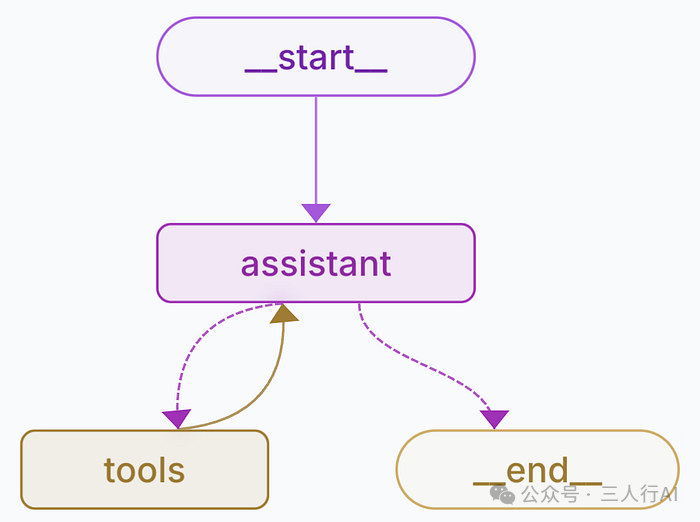

# 3.AI Agent的理论基础

### 3-1.认知科学与AI agent

1.感知-行动循环
2.注意力机制
3.记忆系统
4.学习和适应

In [2]:
class CognitiveAgent:
    def __init__(self):
        self.short_term_memory = []
        self.long_term_memory = {}
        self.attention_focus = None
    
    def perceive(self, environment):
        # 模拟感知过程
        self.short_term_memory = environment[:5]  # 只关注前5个元素
    
    def focus_attention(self):
        # 简单的注意力机制
        self.attention_focus = max(self.short_term_memory, key=lambda x: x['importance'])
    
    def learn(self, experience):
        # 简化的学习过程
        if experience['outcome'] == 'positive':
            self.long_term_memory[experience['action']] = self.long_term_memory.get(experience['action'], 0) + 1
    
    def decide_action(self):
        # 基于长期记忆做决策
        return max(self.long_term_memory, key=self.long_term_memory.get) if self.long_term_memory else 'explore'

# 使用示例
agent = CognitiveAgent()
environment = [{'data': 'A', 'importance': 3}, {'data': 'B', 'importance': 1}, {'data': 'C', 'importance': 5}]
agent.perceive(environment)
agent.focus_attention()
print(f"Agent is focusing on: {agent.attention_focus}")

Agent is focusing on: {'data': 'C', 'importance': 5}


### 3-2.决策理论

1.效用函数--价值量化
2.期望效用--不确定下的平均效用
3.决策树--决策过程的树形结构
4.贝叶斯决策理论--利用概率更新信念